## Applied Machine Learning Homework 1
### Shane Wang tsw2134

In [1]:
# pip install --upgrade --force-reinstall numpy scikit-learn

In [2]:
# pip install seaborn

In [3]:
import sklearn
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
titanic_train = pd.read_csv('titanic/train.csv')
titanic_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
titanic_train.size

10692

In [6]:
titanic_train.shape

(891, 12)

We are trying to predict (train) whether a passenger survived or not from given data.

"Survived" is binary. You either survived the Titanic disaster or you did not. 

The features are sex, age, number of siblings or spouses on the ship, number of parents or children on the ship, the ticket number, fare cost, cabin, and the port of embarkation. There are a total of 891 passenger records.

We can train and compare 2 different modeling approaches:
* Generative: Naive Bayes
* Discriminative: Linear Regression

In [7]:
titanic_train['Survived'].sum()

np.int64(342)

In [8]:
survival_rate = 342/891
1-survival_rate

0.6161616161616161

## Part 1: Data Cleaning

In [9]:
# Checking for empty values
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 1.1 Missing Cabins

In [10]:
# 'Has_Cabin' is true if passenger has a cabin
titanic_train['Has_Cabin'] = titanic_train['Cabin'].notnull()

# Adding a Cabin Section column for first letter
titanic_train['Cabin_Section'] = titanic_train['Cabin'].str[0].fillna(np.nan)
titanic_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Cabin_Section
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,NaN
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,False,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,True,E
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,False,NaN
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,False,NaN
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,False,NaN


### 1.2 Missing Age

In [11]:
# We can take the average age of each cabin class 
pclass_age = titanic_train.groupby('Pclass')['Age'].mean()
pclass_age

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [12]:
# Filling missing ages with the average ages of the socioeconomic classes (Pclass)
def fill_age(row):
    if pd.isna(row['Age']):
        return pclass_age[row['Pclass']]
    else:
        return row['Age']
titanic_train['Age'] = titanic_train.apply(fill_age, axis=1)

### 1.3 Missing Embarked

In [13]:
titanic_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
titanic_train['Embarked'] = titanic_train['Embarked'].fillna('S')

In [15]:
titanic_train.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           0
Has_Cabin          0
Cabin_Section    687
dtype: int64

In [16]:
titanic_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Cabin_Section
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.2500,NaN,S,False,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00000,1,0,PC 17599,71.2833,C85,C,True,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.9250,NaN,S,False,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.1000,C123,S,True,C
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.0500,NaN,S,False,NaN
5,6,0,3,"Moran, Mr. James",male,25.14062,0,0,330877,8.4583,NaN,Q,False,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00000,0,0,17463,51.8625,E46,S,True,E
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00000,3,1,349909,21.0750,NaN,S,False,NaN
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00000,0,2,347742,11.1333,NaN,S,False,NaN
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00000,1,0,237736,30.0708,NaN,C,False,NaN


## Part 2: Feature Engineering

### 2.1 Outlier Analysis

In [17]:
# One hot encoding categorical columns by creating dummies
titanic_encoded = pd.get_dummies(titanic_train, columns=['Sex', 'Embarked', 'Cabin_Section'], prefix=['Sex', 'Embarked', 'Cabin_Section'], drop_first = True)
titanic_encoded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Has_Cabin', 'Sex_male', 'Embarked_Q',
       'Embarked_S', 'Cabin_Section_B', 'Cabin_Section_C', 'Cabin_Section_D',
       'Cabin_Section_E', 'Cabin_Section_F', 'Cabin_Section_G',
       'Cabin_Section_T'],
      dtype='object')

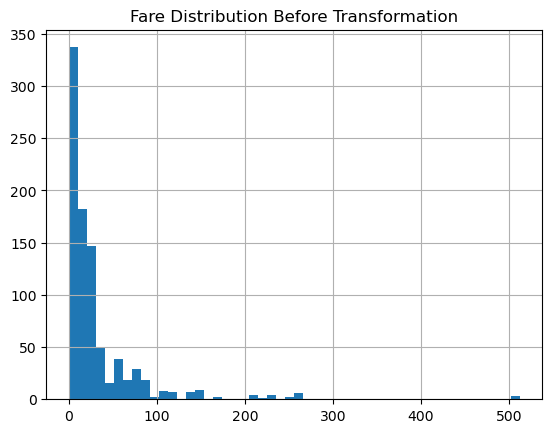

In [18]:
# Checking for outliers, data quality issues, or duplicates
titanic_train['Sex'].value_counts()
titanic_train['Embarked'].value_counts()
titanic_train['Age'].describe()
titanic_train['Fare'].describe()
titanic_train.duplicated().sum()
titanic_train['SibSp'].value_counts()
titanic_train['Parch'].value_counts()
titanic_train[titanic_train['Fare'] > 200][['Pclass', 'Fare', 'Age', 'Sex', 'Embarked']]
titanic_train['Fare'].hist(bins=50)
plt.title('Fare Distribution Before Transformation')
plt.show()

In [19]:
top_fares = titanic_train.sort_values(by='Fare', ascending=False).head(20)
print(top_fares)

     PassengerId  Survived  Pclass  \
258          259         1       1   
737          738         1       1   
679          680         1       1   
88            89         1       1   
27            28         0       1   
341          342         1       1   
438          439         0       1   
311          312         1       1   
742          743         1       1   
118          119         0       1   
299          300         1       1   
557          558         0       1   
700          701         1       1   
380          381         1       1   
716          717         1       1   
527          528         0       1   
377          378         0       1   
730          731         1       1   
779          780         1       1   
689          690         1       1   

                                                  Name     Sex        Age  \
258                                   Ward, Miss. Anna  female  35.000000   
737                             Lesurer, Mr. Gu

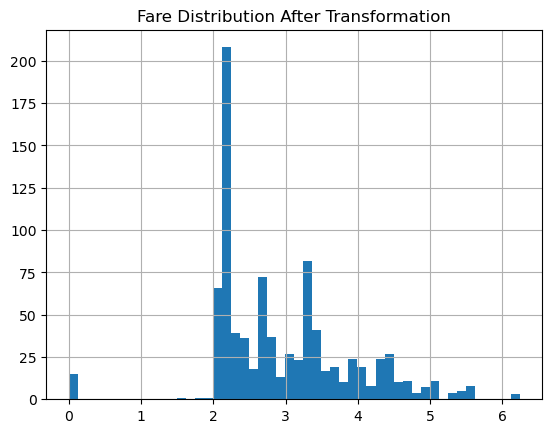

In [20]:
# Log-scaling 'Fare' since highly skewed with outliers >200
titanic_encoded['Fare'] = np.log1p(titanic_encoded['Fare'])
titanic_encoded['Fare'].hist(bins=50)
plt.title('Fare Distribution After Transformation')
plt.show()

## Part 3: Model Training and Evaluation

### 3.1 Splitting into training and test set

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = titanic_encoded['Survived']
X = titanic_encoded.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1) # drop useless or provided parameters

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Standardize all features for Linear Regression and LASSO since Age ranges vastly while other features are binary
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.2 Naive Bayes Classifier: Gaussian

In [23]:
from sklearn.naive_bayes import GaussianNB

# We use NB Gaussian because there are continuous features like age and fare.
# alpha = 1.0
nb1 = GaussianNB(var_smoothing=1)
nb1.fit(X_train, y_train)
y_pred_1 = nb1.predict(X_test)
y_prob_1 = nb1.predict_proba(X_test)[:, 1]

# alpha = 0.01
nb2 = GaussianNB(var_smoothing=0.01)
nb2.fit(X_train, y_train)
y_pred_2 = nb2.predict(X_test)
y_prob_2 = nb2.predict_proba(X_test)[:, 1]

# alpha = 0.001
nb3 = GaussianNB(var_smoothing=0.001)
nb3.fit(X_train, y_train)
y_pred_3 = nb3.predict(X_test)
y_prob_3 = nb3.predict_proba(X_test)[:, 1]

### 3.2.1 Gaussian $\alpha = 1.0$ Evaluation

Accuracy: 0.587
AUC Score: 0.580

Confusion Matrix:
[[105   0]
 [ 74   0]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.59      1.00      0.74       105
    Survived       0.00      0.00      0.00        74

    accuracy                           0.59       179
   macro avg       0.29      0.50      0.37       179
weighted avg       0.34      0.59      0.43       179



/Users/shanewang09/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shanewang09/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shanewang09/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

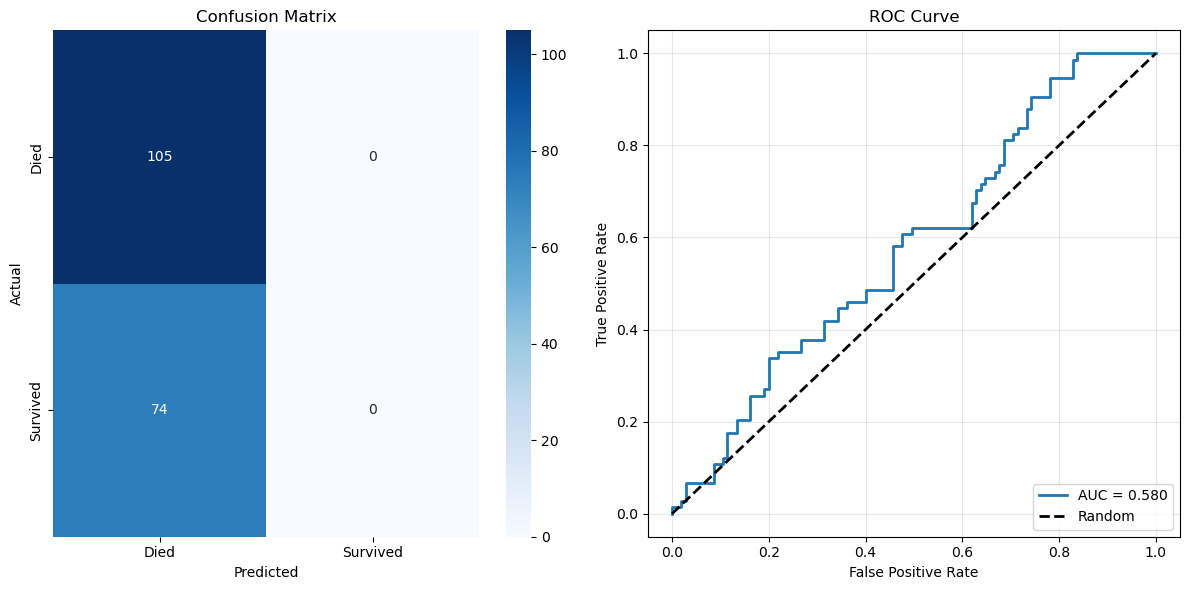

In [24]:
# alpha = 1.0 Evaluation, Courtesy of Claude:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

acc = accuracy_score(y_test, y_pred_1)
cm = confusion_matrix(y_test, y_pred_1)
fpr, tpr, _ = roc_curve(y_test, y_prob_1)
auc_score = auc(fpr, tpr)

print(f"Accuracy: {acc:.3f}")
print(f"AUC Score: {auc_score:.3f}")
print(f"\nConfusion Matrix:\n{cm}")

# Stats 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_1, target_names=['Died', 'Survived'])) # note that the model doesn't predict any survivors, so there's a division by zero

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2.2 Gaussian $\alpha = 0.01$ Evaluation

Accuracy: 0.693
AUC Score: 0.822

Confusion Matrix:
[[94 11]
 [44 30]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.68      0.90      0.77       105
    Survived       0.73      0.41      0.52        74

    accuracy                           0.69       179
   macro avg       0.71      0.65      0.65       179
weighted avg       0.70      0.69      0.67       179



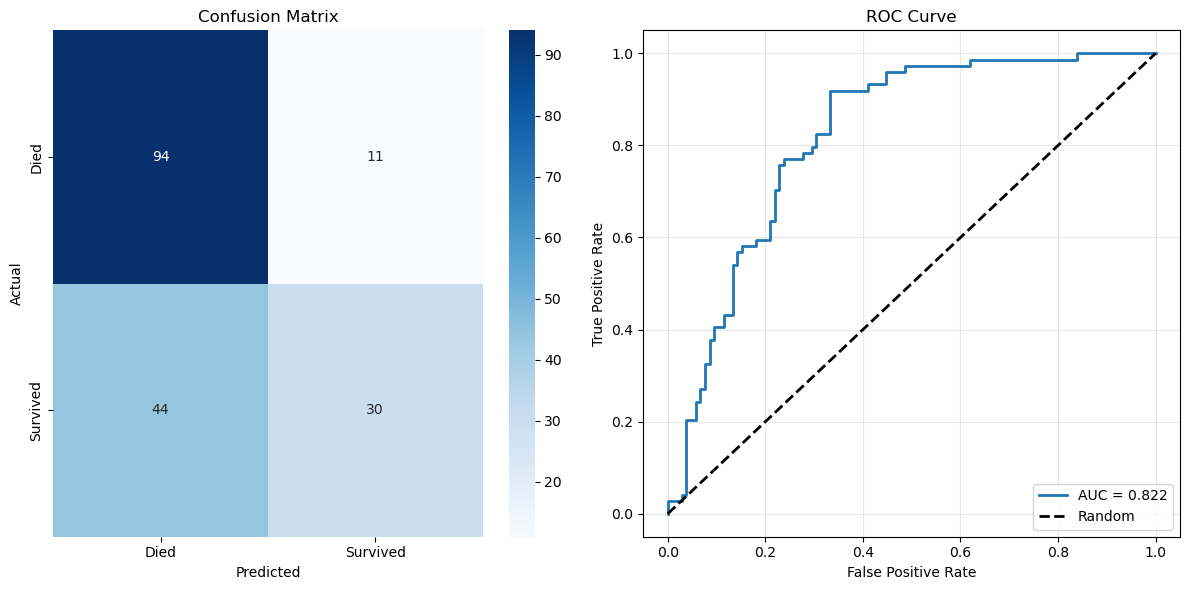

In [25]:
# alpha = 0.01 Evaluation, Courtesy of Claude:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

acc = accuracy_score(y_test, y_pred_2)
cm = confusion_matrix(y_test, y_pred_2)
fpr, tpr, _ = roc_curve(y_test, y_prob_2)
auc_score = auc(fpr, tpr)

print(f"Accuracy: {acc:.3f}")
print(f"AUC Score: {auc_score:.3f}")
print(f"\nConfusion Matrix:\n{cm}")

# Stats 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_2, target_names=['Died', 'Survived']))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2.3 Gaussian $\alpha = 0.001$ Evaluation

Accuracy: 0.754
AUC Score: 0.847

Confusion Matrix:
[[93 12]
 [32 42]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.74      0.89      0.81       105
    Survived       0.78      0.57      0.66        74

    accuracy                           0.75       179
   macro avg       0.76      0.73      0.73       179
weighted avg       0.76      0.75      0.75       179



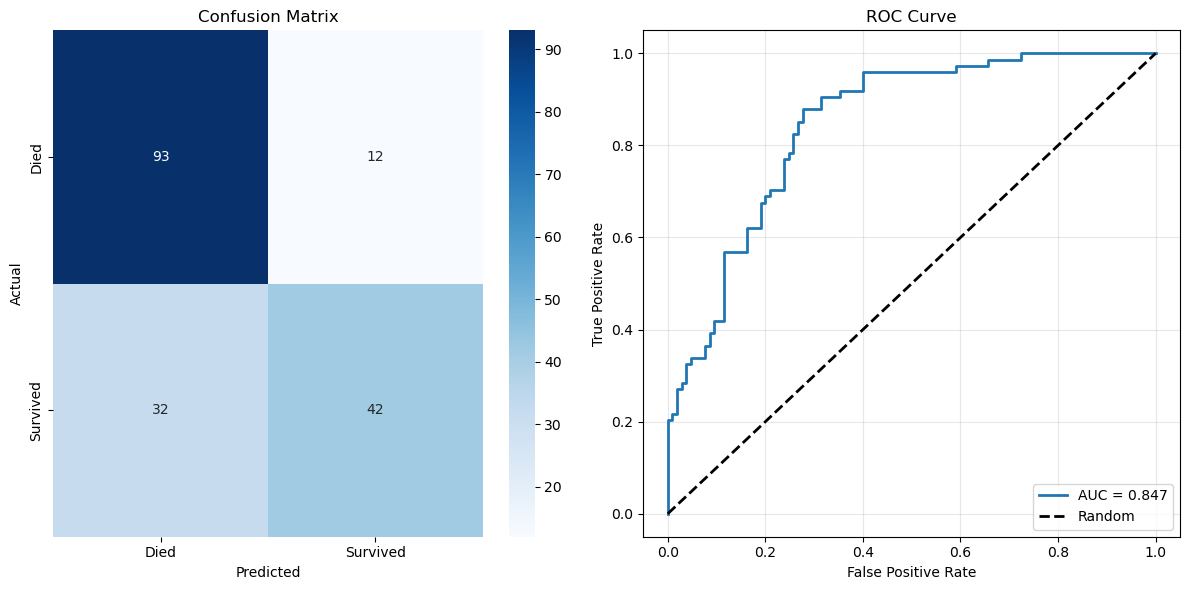

In [26]:
# alpha = 0.001 Evaluation, Courtesy of Claude:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

acc = accuracy_score(y_test, y_pred_3)
cm = confusion_matrix(y_test, y_pred_3)
fpr, tpr, _ = roc_curve(y_test, y_prob_3)
auc_score = auc(fpr, tpr)

print(f"Accuracy: {acc:.3f}")
print(f"AUC Score: {auc_score:.3f}")
print(f"\nConfusion Matrix:\n{cm}")

# Stats 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_3, target_names=['Died', 'Survived']))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Linear Regression

In [27]:
# Linear Regression with threshold 0.5
from sklearn.linear_model import LinearRegression

linear_model_scaled = LinearRegression()
linear_model_scaled.fit(X_train_scaled, y_train)

y_pred_continuous = linear_model_scaled.predict(X_test_scaled)

y_pred_linear = (y_pred_continuous >= 0.5).astype(int)

accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear Regression Accuracy: {accuracy_linear:.3f}")

Linear Regression Accuracy: 0.793


### 3.3.1 Linear Regression Evaluation

Accuracy: 0.793
AUC Score: 0.884

Confusion Matrix:
[[88 17]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.84      0.83       105
    Survived       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



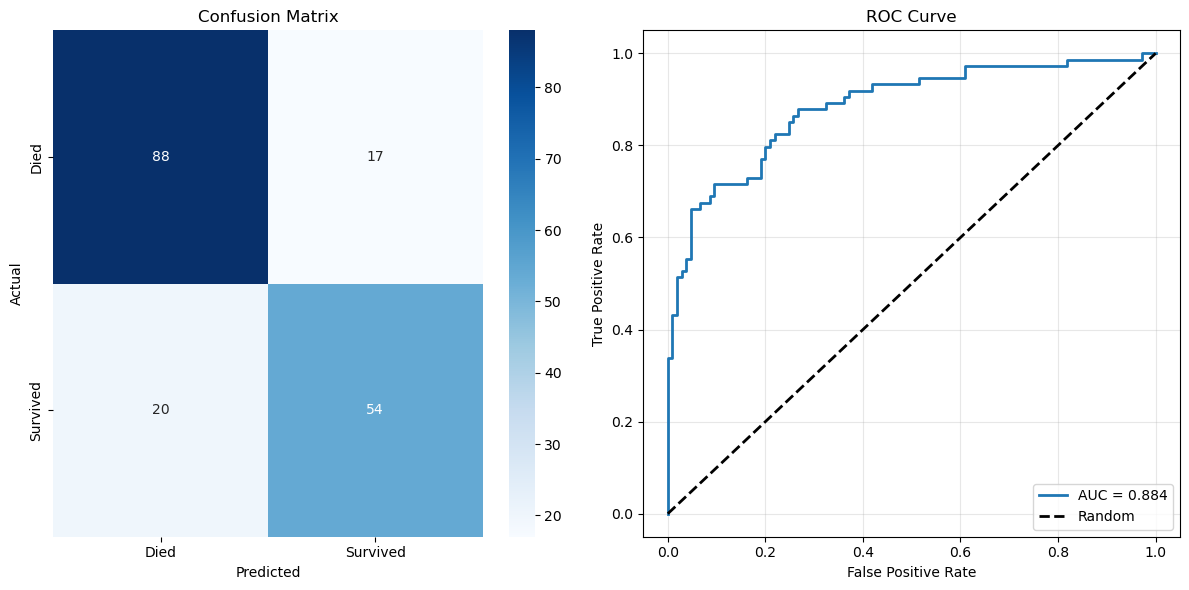

In [28]:
# Linear Regression Evaluation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

acc = accuracy_score(y_test, y_pred_linear)
cm = confusion_matrix(y_test, y_pred_linear)
fpr, tpr, _ = roc_curve(y_test, y_pred_continuous)
auc_score = auc(fpr, tpr)

print(f"Accuracy: {acc:.3f}")
print(f"AUC Score: {auc_score:.3f}")
print(f"\nConfusion Matrix:\n{cm}")

# Stats 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear, target_names=['Died', 'Survived']))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3.2 Ridge (L2 Regularization)

In [29]:
# Ridge regression (L2 regularization) to prevent overfitting
from sklearn.linear_model import Ridge

alpha = 0.01

ridge_model = Ridge(alpha, max_iter=10000)
ridge_model.fit(X_train_scaled, y_train)

y_pred_continuous_ridge = ridge_model.predict(X_test_scaled)
y_pred_ridge = (y_pred_continuous_ridge >= 0.5).astype(int)

accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
print(f"Ridge (alpha={alpha}): Accuracy = {accuracy_ridge:.3f}")

Ridge (alpha=0.01): Accuracy = 0.793


### 3.3.3 Ridge Evaluation

Accuracy: 0.7933
AUC Score: 0.8839

Confusion Matrix:
[[88 17]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.84      0.83       105
    Survived       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



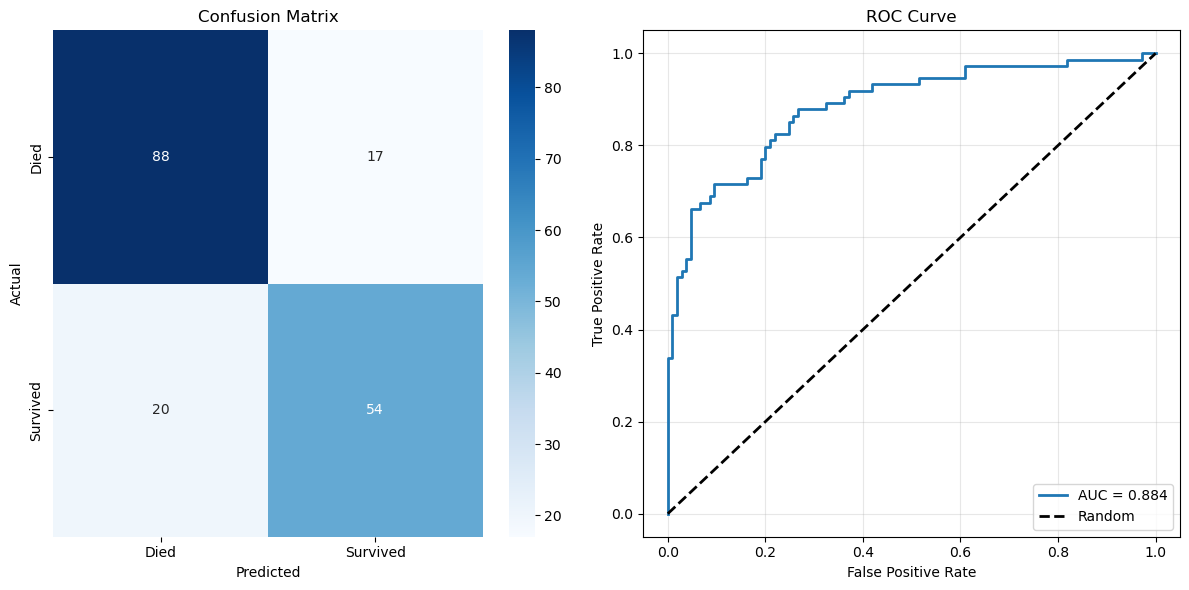

In [30]:
# Ridge Evaluation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

acc = accuracy_score(y_test, y_pred_ridge)
cm = confusion_matrix(y_test, y_pred_ridge)
fpr, tpr, _ = roc_curve(y_test, y_pred_continuous_ridge)
auc_score = auc(fpr, tpr)

print(f"Accuracy: {acc:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

# Stats 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ridge, target_names=['Died', 'Survived']))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3.4 LASSO (L1 Regularization)

In [31]:
# LASSO regression (L1 regularization) to prevent overfitting
from sklearn.linear_model import Lasso

alpha = 0.01

lasso_model = Lasso(alpha, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_pred_continuous_lasso = lasso_model.predict(X_test_scaled)
y_pred_lasso = (y_pred_continuous_lasso >= 0.5).astype(int)

accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"LASSO (alpha={alpha}): Accuracy = {accuracy_lasso:.3f}")

LASSO (alpha=0.01): Accuracy = 0.788


### 3.3.5 LASSO Evaluation

Accuracy: 0.7877
AUC Score: 0.8811

Confusion Matrix:
[[86 19]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.82      0.82       105
    Survived       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



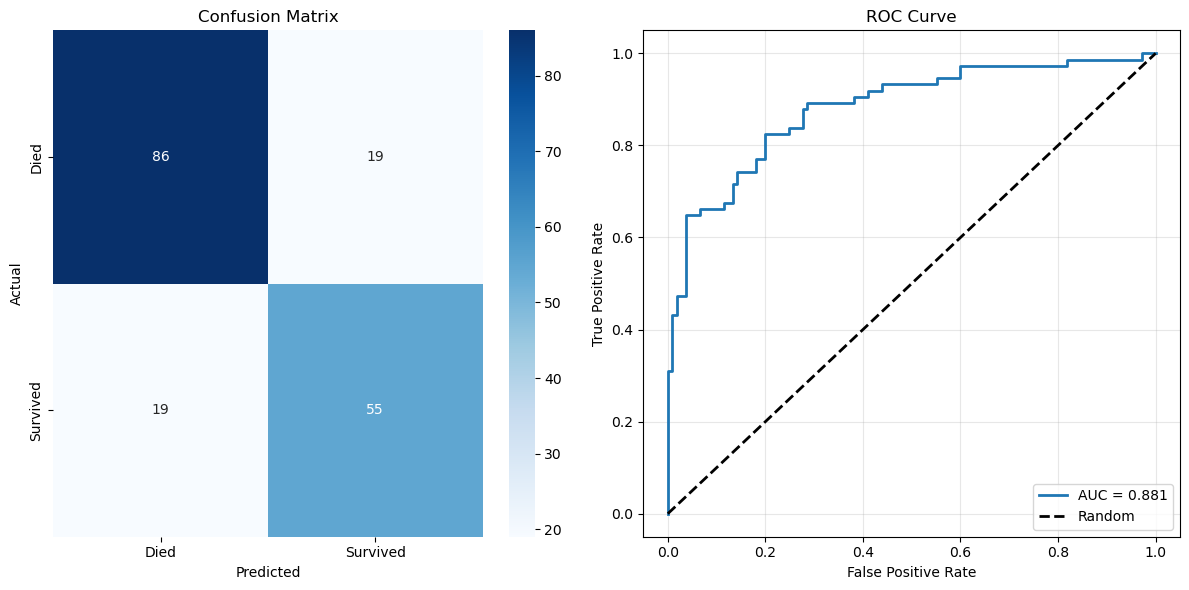

In [32]:
# LASSO Evaluation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

acc = accuracy_score(y_test, y_pred_lasso)
cm = confusion_matrix(y_test, y_pred_lasso)
fpr, tpr, _ = roc_curve(y_test, y_pred_continuous_lasso)
auc_score = auc(fpr, tpr)

print(f"Accuracy: {acc:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

# Stats 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lasso, target_names=['Died', 'Survived']))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()